# Taller - Conversion y Manipulacion de Espacios de Color (Python)

Este notebook desarrolla la seccion de Python del taller:
1. Conversion entre espacios de color
2. Visualizacion de espacios de color
3. Segmentacion por color
4. Manipulacion de color
5. Color grading
6. Paletas de colores
7. Analisis de histogramas

Todos los resultados se exportan en `../media` con prefijo `python_`.

In [13]:
%%capture
%pip install numpy matplotlib opencv-python scikit-image

In [11]:
from pathlib import Path
import os

import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import exposure

plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['axes.grid'] = False

MEDIA_DIR = (Path('..') / 'media').resolve()
MEDIA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_PREFIX = 'python_'
NOTEBOOK_DIR = Path.cwd().resolve()

def output_path(name: str, extension: str = 'png') -> Path:
    """Build a standardized output path in ../media."""
    sanitized_name = name.strip().lower().replace(' ', '_')
    return MEDIA_DIR / f'{OUTPUT_PREFIX}{sanitized_name}.{extension}'

def to_relative_display(path: Path) -> str:
    """Convert absolute paths to relative paths for safe console output."""
    path = Path(path)
    if not path.is_absolute():
        return str(path)
    return os.path.relpath(path, start=NOTEBOOK_DIR)

def save_rgb_image(image_rgb: np.ndarray, name: str) -> Path:
    """Save an RGB image to disk using OpenCV (which expects BGR)."""
    path = output_path(name)
    image_bgr = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)
    cv2.imwrite(str(path), image_bgr)
    return path

def save_gray_image(image_gray: np.ndarray, name: str) -> Path:
    """Save a single-channel image."""
    path = output_path(name)
    cv2.imwrite(str(path), image_gray)
    return path

def save_current_figure(name: str) -> Path:
    """Save the current matplotlib figure."""
    path = output_path(name)
    plt.savefig(path, dpi=160, bbox_inches='tight')
    return path

print(f'Carpeta de salida: {to_relative_display(MEDIA_DIR)}')

Carpeta de salida: ../media


Imagen base: ../media/python_input_image.png
Resolucion: 720 x 480


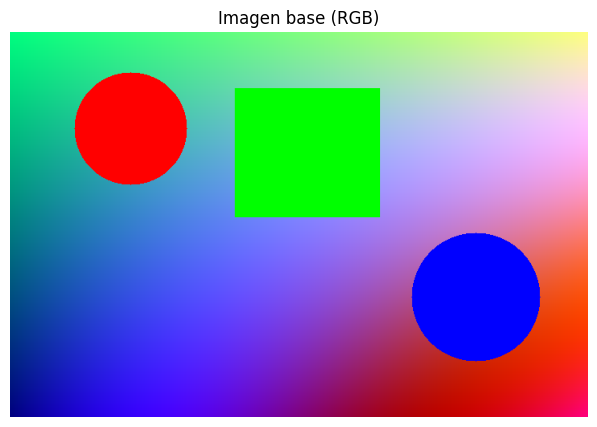

In [12]:
# Carga de imagen base.
# Si no existe imagen de entrada, se crea una sintetica colorida para que el taller sea ejecutable.
candidate_paths = [
    Path('input_image.png'),
    Path('input_image.jpg'),
    MEDIA_DIR / 'python_input_image.png',
    MEDIA_DIR / 'input_image.png',
    MEDIA_DIR / 'input_image.jpg',
]

image_bgr = None
used_path = None
for candidate in candidate_paths:
    if candidate.exists():
        loaded = cv2.imread(str(candidate))
        if loaded is not None:
            image_bgr = loaded
            used_path = candidate
            break

if image_bgr is None:
    height, width = 480, 720
    x = np.linspace(0, 1, width, dtype=np.float32)
    y = np.linspace(0, 1, height, dtype=np.float32)
    xx, yy = np.meshgrid(x, y)

    synthetic_rgb = np.zeros((height, width, 3), dtype=np.uint8)
    synthetic_rgb[..., 0] = np.clip(255 * xx, 0, 255).astype(np.uint8)
    synthetic_rgb[..., 1] = np.clip(255 * (1 - yy), 0, 255).astype(np.uint8)
    synthetic_rgb[..., 2] = np.clip(255 * (0.5 + 0.5 * np.sin(2 * np.pi * xx * yy)), 0, 255).astype(np.uint8)

    cv2.circle(synthetic_rgb, center=(150, 120), radius=70, color=(255, 0, 0), thickness=-1)
    cv2.rectangle(synthetic_rgb, (280, 70), (460, 230), color=(0, 255, 0), thickness=-1)
    cv2.circle(synthetic_rgb, center=(580, 330), radius=80, color=(0, 0, 255), thickness=-1)

    image_rgb = synthetic_rgb
    save_rgb_image(image_rgb, 'input_image')
    used_path = output_path('input_image')
else:
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

print(f'Imagen base: {to_relative_display(used_path)}')
print(f'Resolucion: {image_rgb.shape[1]} x {image_rgb.shape[0]}')

plt.figure(figsize=(8, 5))
plt.imshow(image_rgb)
plt.title('Imagen base (RGB)')
plt.axis('off')
save_current_figure('base_image_preview')
plt.show()

## 1) Conversion entre espacios de color

RGB (OpenCV uint8)
  - R: [0, 255]
  - G: [0, 255]
  - B: [0, 255]

HSV (OpenCV)
  - H: [0, 179]
  - S: [0, 255]
  - V: [0, 255]

HSL/HLS (OpenCV)
  - H: [0, 179]
  - L: [0, 255]
  - S: [0, 255]

LAB (OpenCV uint8)
  - L: [0, 255]
  - A: [0, 255]
  - B: [0, 255]

YCrCb (OpenCV)
  - Y: [0, 255]
  - Cr: [0, 255]
  - Cb: [0, 255]

Grayscale
  - Gray: [0, 255]



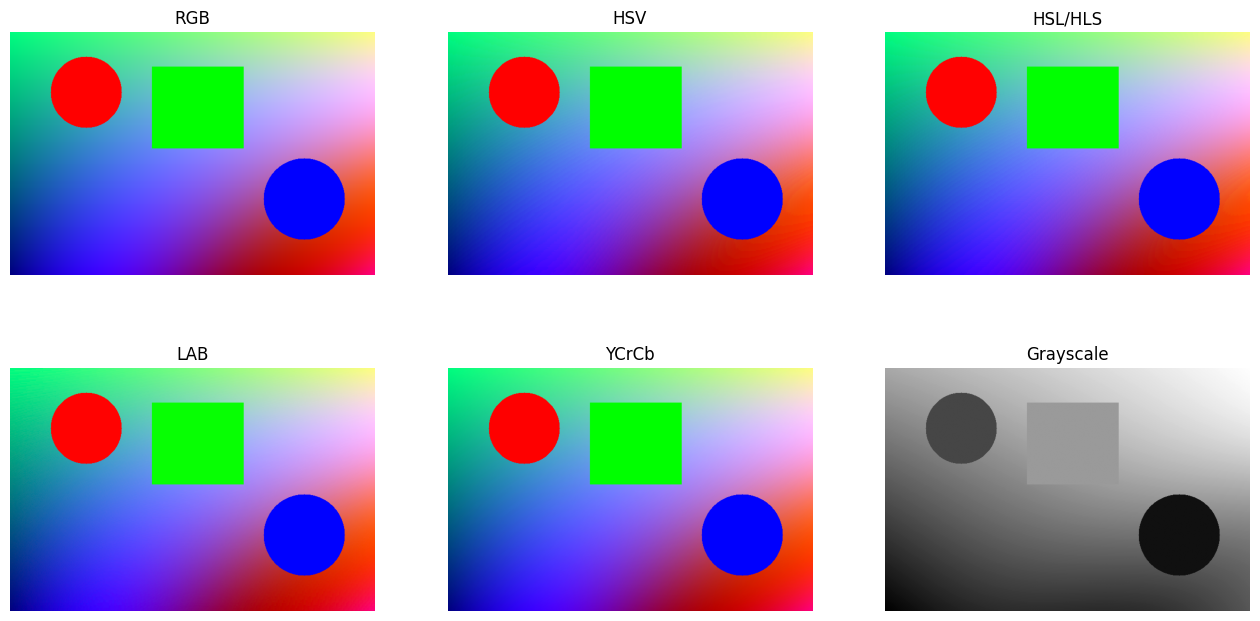

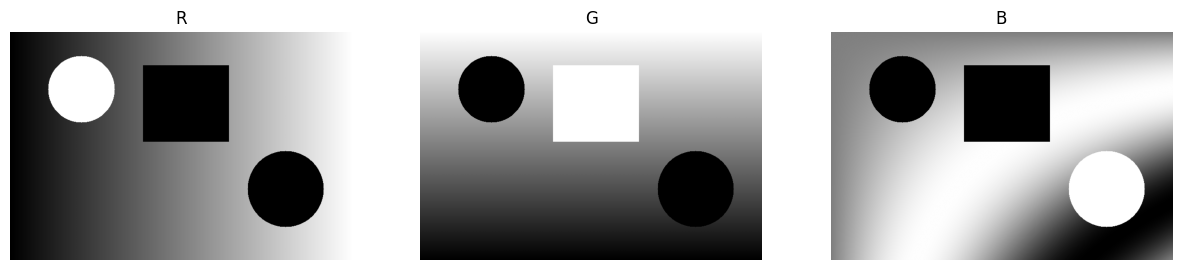

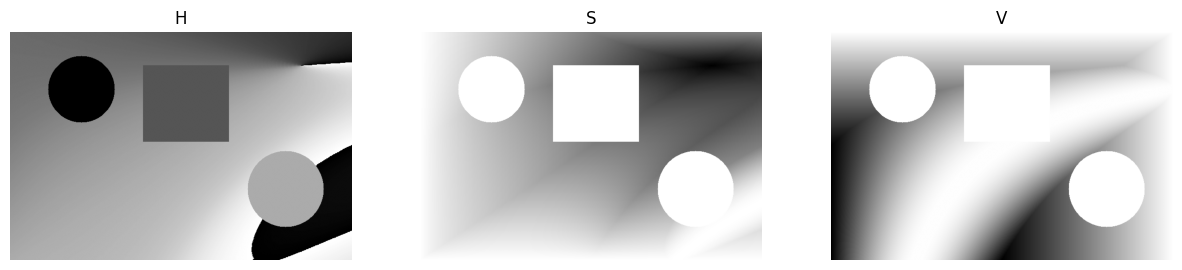

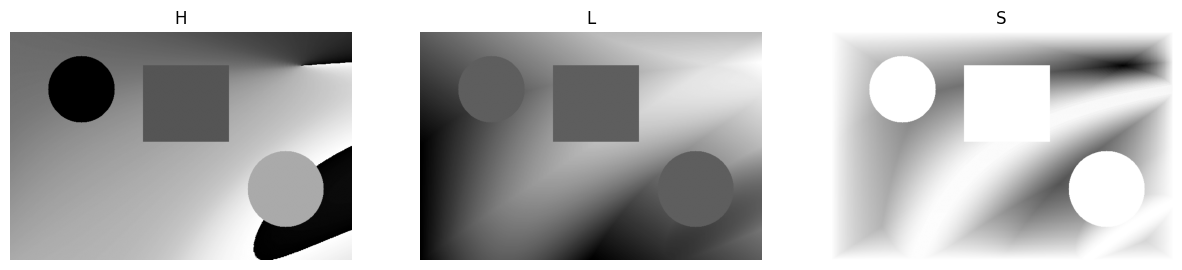

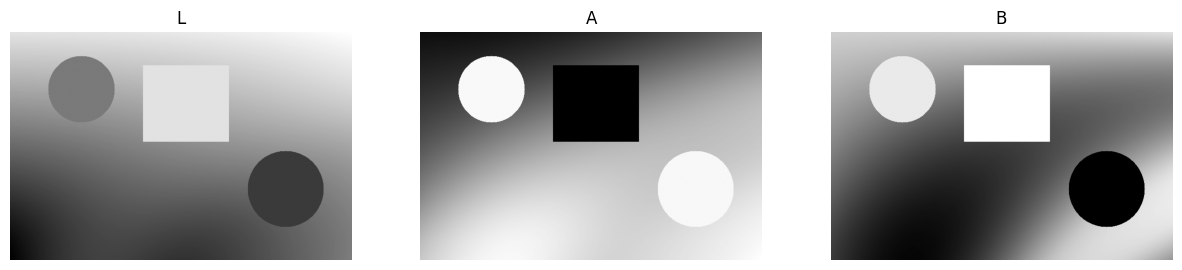

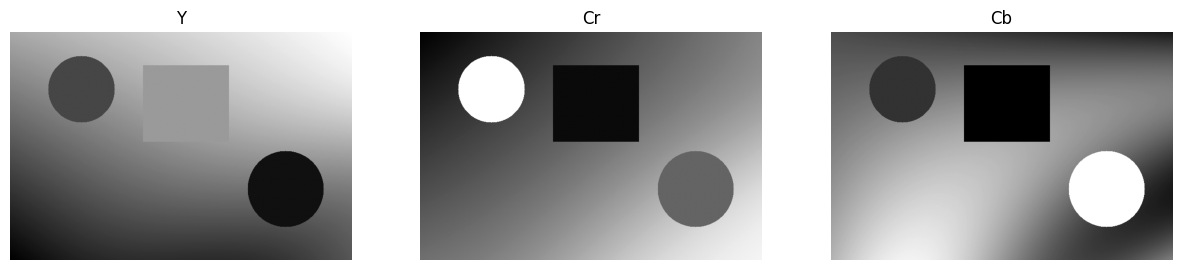

In [3]:
# Conversiones principales solicitadas en la guia.
hsv_image = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2HSV)
hsl_image = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2HLS)
lab_image = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2LAB)
ycrcb_image = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2YCrCb)
gray_image = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

save_gray_image(gray_image, 'gray_image')

space_ranges = {
    'RGB (OpenCV uint8)': {'R': '[0, 255]', 'G': '[0, 255]', 'B': '[0, 255]'},
    'HSV (OpenCV)': {'H': '[0, 179]', 'S': '[0, 255]', 'V': '[0, 255]'},
    'HSL/HLS (OpenCV)': {'H': '[0, 179]', 'L': '[0, 255]', 'S': '[0, 255]'},
    'LAB (OpenCV uint8)': {'L': '[0, 255]', 'A': '[0, 255]', 'B': '[0, 255]'},
    'YCrCb (OpenCV)': {'Y': '[0, 255]', 'Cr': '[0, 255]', 'Cb': '[0, 255]'},
    'Grayscale': {'Gray': '[0, 255]'}
}

for space_name, ranges in space_ranges.items():
    print(space_name)
    for channel_name, channel_range in ranges.items():
        print(f'  - {channel_name}: {channel_range}')
    print()

plt.figure(figsize=(16, 8))
overview_items = [
    ('RGB', image_rgb, None),
    ('HSV', cv2.cvtColor(hsv_image, cv2.COLOR_HSV2RGB), None),
    ('HSL/HLS', cv2.cvtColor(hsl_image, cv2.COLOR_HLS2RGB), None),
    ('LAB', cv2.cvtColor(lab_image, cv2.COLOR_LAB2RGB), None),
    ('YCrCb', cv2.cvtColor(ycrcb_image, cv2.COLOR_YCrCb2RGB), None),
    ('Grayscale', gray_image, 'gray')
]

for index, (title, image_to_show, cmap) in enumerate(overview_items, start=1):
    plt.subplot(2, 3, index)
    plt.imshow(image_to_show, cmap=cmap)
    plt.title(title)
    plt.axis('off')

save_current_figure('conversion_overview')
plt.show()

def plot_channels(image: np.ndarray, channel_names: list, figure_name: str):
    plt.figure(figsize=(15, 4))
    for channel_index, channel_name in enumerate(channel_names):
        plt.subplot(1, len(channel_names), channel_index + 1)
        plt.imshow(image[..., channel_index], cmap='gray')
        plt.title(channel_name)
        plt.axis('off')
    save_current_figure(figure_name)
    plt.show()

plot_channels(image_rgb, ['R', 'G', 'B'], 'channels_rgb')
plot_channels(hsv_image, ['H', 'S', 'V'], 'channels_hsv')
plot_channels(hsl_image, ['H', 'L', 'S'], 'channels_hsl')
plot_channels(lab_image, ['L', 'A', 'B'], 'channels_lab')
plot_channels(ycrcb_image, ['Y', 'Cr', 'Cb'], 'channels_ycrcb')

## 2) Visualizacion de espacios de color

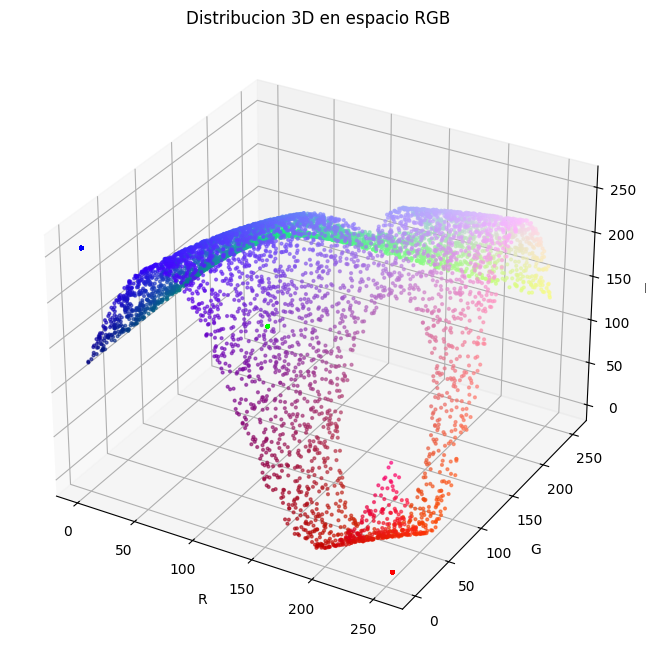

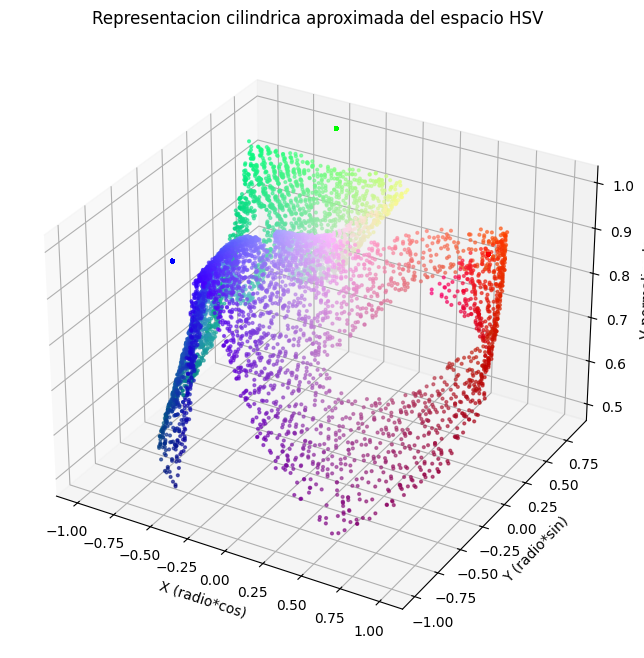

In [4]:
# Muestreo de pixeles para graficas 3D sin sobrecargar memoria.
flat_rgb = image_rgb.reshape(-1, 3)
sample_size = min(8000, flat_rgb.shape[0])
rng = np.random.default_rng(seed=42)
sample_indices = rng.choice(flat_rgb.shape[0], size=sample_size, replace=False)
rgb_points = flat_rgb[sample_indices]

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(rgb_points[:, 0], rgb_points[:, 1], rgb_points[:, 2], c=rgb_points / 255.0, s=4, alpha=0.6)
ax.set_xlabel('R')
ax.set_ylabel('G')
ax.set_zlabel('B')
ax.set_title('Distribucion 3D en espacio RGB')
save_current_figure('rgb_3d_scatter')
plt.show()

hsv_points = hsv_image.reshape(-1, 3)[sample_indices]
h = hsv_points[:, 0].astype(np.float32)
s = hsv_points[:, 1].astype(np.float32)
v = hsv_points[:, 2].astype(np.float32)

theta = (h / 179.0) * 2 * np.pi
radius = s / 255.0
z = v / 255.0
x = radius * np.cos(theta)
y = radius * np.sin(theta)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x, y, z, c=rgb_points / 255.0, s=4, alpha=0.6)
ax.set_xlabel('X (radio*cos)')
ax.set_ylabel('Y (radio*sin)')
ax.set_zlabel('V normalizado')
ax.set_title('Representacion cilindrica aproximada del espacio HSV')
save_current_figure('hsv_cylindrical_scatter')
plt.show()

## 3) Segmentacion por color en HSV

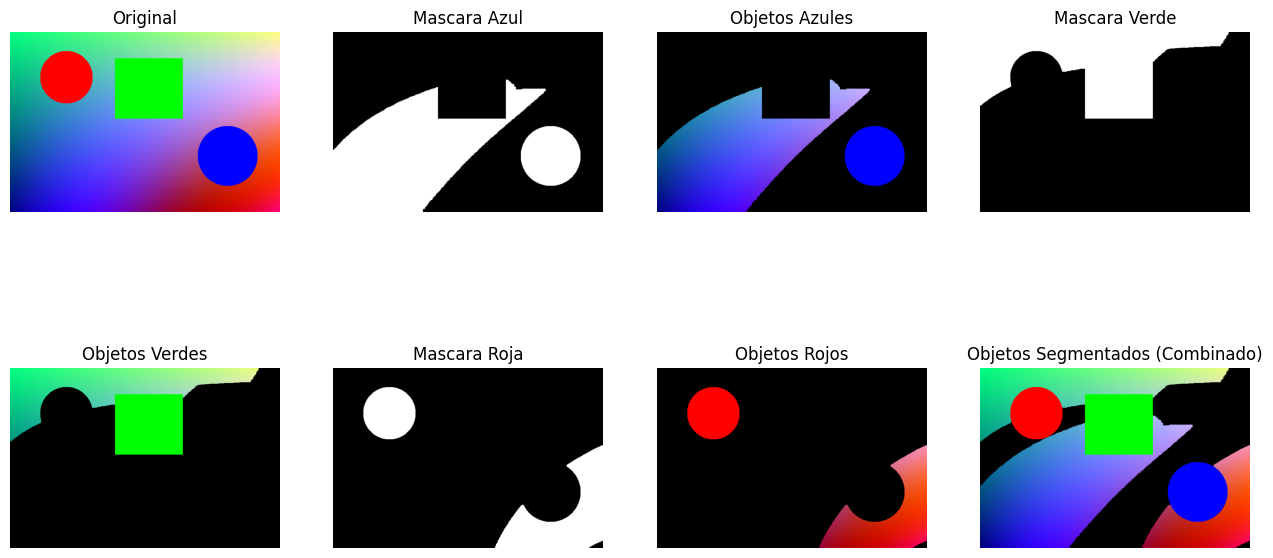

In [5]:
seg_hsv = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2HSV)

# Rangos HSV (OpenCV): H in [0, 179].
lower_blue = np.array([100, 80, 50], dtype=np.uint8)
upper_blue = np.array([130, 255, 255], dtype=np.uint8)

lower_green = np.array([35, 60, 40], dtype=np.uint8)
upper_green = np.array([85, 255, 255], dtype=np.uint8)

lower_red_1 = np.array([0, 80, 40], dtype=np.uint8)
upper_red_1 = np.array([10, 255, 255], dtype=np.uint8)
lower_red_2 = np.array([170, 80, 40], dtype=np.uint8)
upper_red_2 = np.array([179, 255, 255], dtype=np.uint8)

mask_blue = cv2.inRange(seg_hsv, lower_blue, upper_blue)
mask_green = cv2.inRange(seg_hsv, lower_green, upper_green)
mask_red = cv2.inRange(seg_hsv, lower_red_1, upper_red_1) | cv2.inRange(seg_hsv, lower_red_2, upper_red_2)

kernel = np.ones((5, 5), np.uint8)
def clean_mask(mask: np.ndarray) -> np.ndarray:
    opened = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel)
    return closed

mask_blue_clean = clean_mask(mask_blue)
mask_green_clean = clean_mask(mask_green)
mask_red_clean = clean_mask(mask_red)

blue_objects = cv2.bitwise_and(image_rgb, image_rgb, mask=mask_blue_clean)
green_objects = cv2.bitwise_and(image_rgb, image_rgb, mask=mask_green_clean)
red_objects = cv2.bitwise_and(image_rgb, image_rgb, mask=mask_red_clean)

save_gray_image(mask_blue_clean, 'mask_blue')
save_gray_image(mask_green_clean, 'mask_green')
save_gray_image(mask_red_clean, 'mask_red')
save_rgb_image(blue_objects, 'objects_blue')
save_rgb_image(green_objects, 'objects_green')
save_rgb_image(red_objects, 'objects_red')

plt.figure(figsize=(16, 8))
visuals = [
    ('Original', image_rgb, None),
    ('Mascara Azul', mask_blue_clean, 'gray'),
    ('Objetos Azules', blue_objects, None),
    ('Mascara Verde', mask_green_clean, 'gray'),
    ('Objetos Verdes', green_objects, None),
    ('Mascara Roja', mask_red_clean, 'gray'),
    ('Objetos Rojos', red_objects, None)
]

for index, (title, image_to_show, cmap) in enumerate(visuals, start=1):
    plt.subplot(2, 4, index)
    plt.imshow(image_to_show, cmap=cmap)
    plt.title(title)
    plt.axis('off')

plt.subplot(2, 4, 8)
combined_mask = np.maximum.reduce([mask_blue_clean, mask_green_clean, mask_red_clean])
combined_objects = cv2.bitwise_and(image_rgb, image_rgb, mask=combined_mask)
plt.imshow(combined_objects)
plt.title('Objetos Segmentados (Combinado)')
plt.axis('off')

save_rgb_image(combined_objects, 'objects_combined')
save_current_figure('segmentation_summary')
plt.show()

## 4) Manipulacion de color

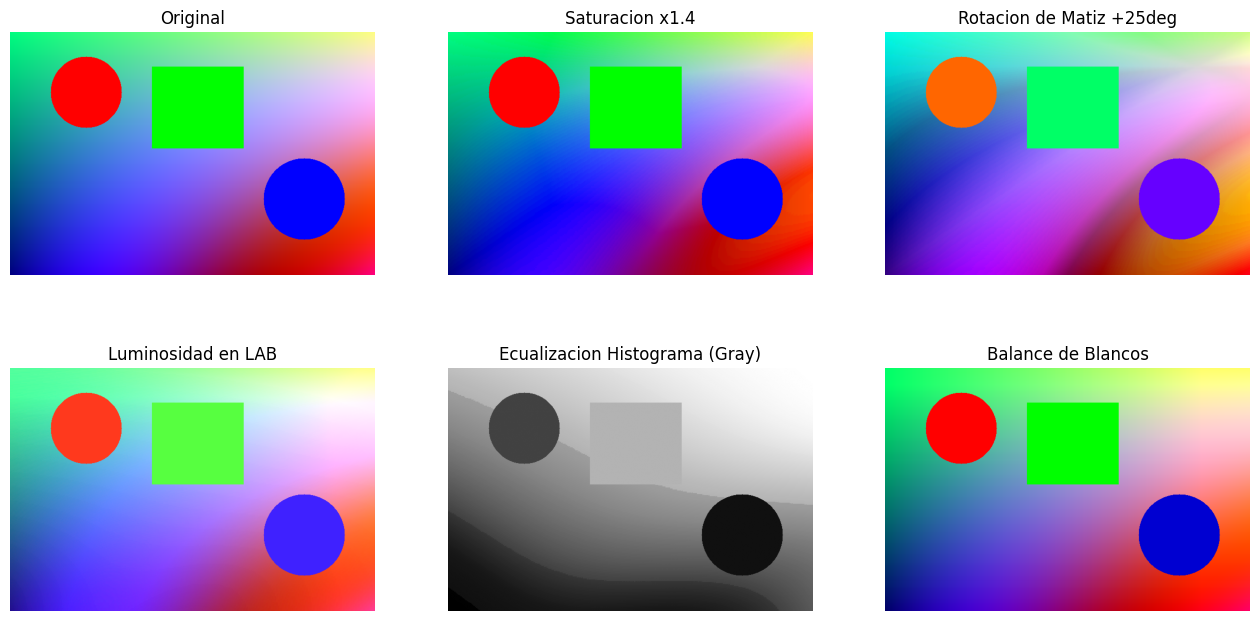

In [6]:
def adjust_saturation(image_rgb: np.ndarray, factor: float) -> np.ndarray:
    hsv = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2HSV).astype(np.float32)
    hsv[..., 1] = np.clip(hsv[..., 1] * factor, 0, 255)
    return cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)

def rotate_hue(image_rgb: np.ndarray, degrees: float) -> np.ndarray:
    # En OpenCV, H in [0, 179], equivalente a [0, 360) grados.
    shift = int(round(degrees / 2.0))
    hsv = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2HSV)
    hsv[..., 0] = (hsv[..., 0].astype(np.int16) + shift) % 180
    return cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)

def modify_lab_luminance(image_rgb: np.ndarray, alpha: float, beta: float) -> np.ndarray:
    lab = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2LAB)
    l_channel, a_channel, b_channel = cv2.split(lab)
    l_adjusted = np.clip(alpha * l_channel + beta, 0, 255).astype(np.uint8)
    merged = cv2.merge((l_adjusted, a_channel, b_channel))
    return cv2.cvtColor(merged, cv2.COLOR_LAB2RGB)

def gray_world_white_balance(image_rgb: np.ndarray) -> np.ndarray:
    image_float = image_rgb.astype(np.float32)
    channel_means = image_float.mean(axis=(0, 1))
    global_mean = channel_means.mean()
    scale = global_mean / (channel_means + 1e-8)
    balanced = np.clip(image_float * scale, 0, 255).astype(np.uint8)
    return balanced

saturation_up_image = adjust_saturation(image_rgb, factor=1.4)
hue_rotated_image = rotate_hue(image_rgb, degrees=25)
lab_luminance_image = modify_lab_luminance(image_rgb, alpha=1.08, beta=12)
hist_equalized_gray = cv2.equalizeHist(gray_image)
white_balanced_image = gray_world_white_balance(image_rgb)

save_rgb_image(saturation_up_image, 'manip_saturation_up')
save_rgb_image(hue_rotated_image, 'manip_hue_rotated')
save_rgb_image(lab_luminance_image, 'manip_lab_luminance')
save_gray_image(hist_equalized_gray, 'manip_hist_equalized_gray')
save_rgb_image(white_balanced_image, 'manip_white_balance')

plt.figure(figsize=(16, 8))
manipulations = [
    ('Original', image_rgb, None),
    ('Saturacion x1.4', saturation_up_image, None),
    ('Rotacion de Matiz +25deg', hue_rotated_image, None),
    ('Luminosidad en LAB', lab_luminance_image, None),
    ('Ecualizacion Histograma (Gray)', hist_equalized_gray, 'gray'),
    ('Balance de Blancos', white_balanced_image, None)
]

for index, (title, image_to_show, cmap) in enumerate(manipulations, start=1):
    plt.subplot(2, 3, index)
    plt.imshow(image_to_show, cmap=cmap)
    plt.title(title)
    plt.axis('off')

save_current_figure('manipulation_summary')
plt.show()

## 5) Color grading

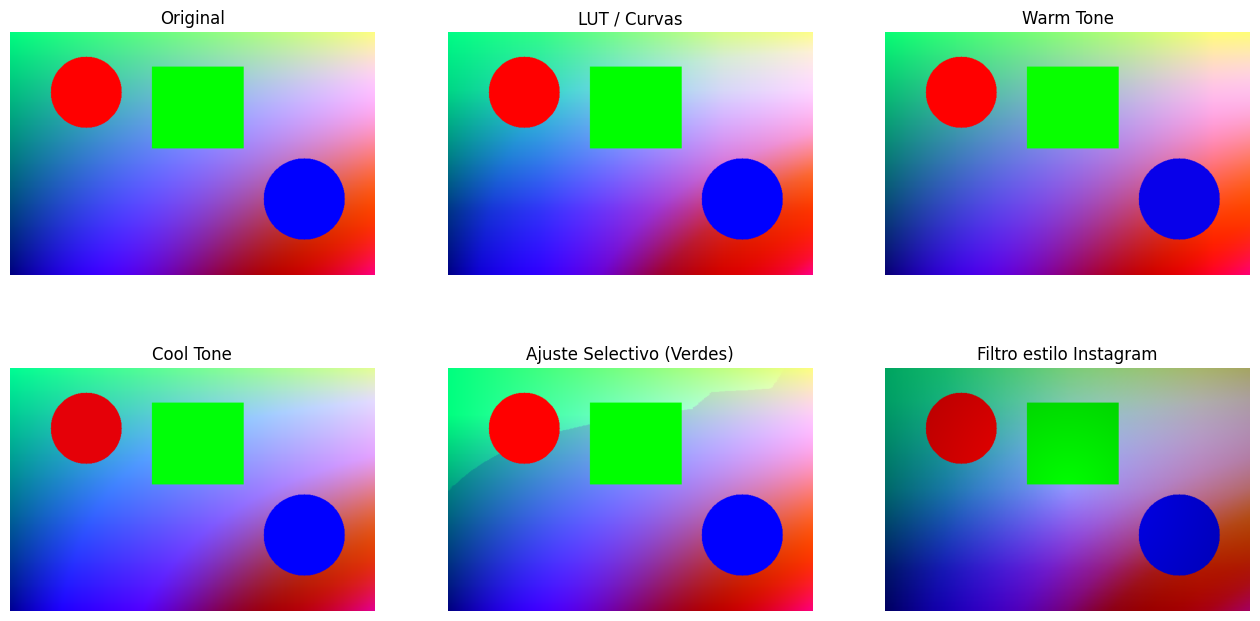

In [7]:
def apply_channel_lut(image_rgb: np.ndarray, x_points: np.ndarray, y_points: np.ndarray) -> np.ndarray:
    lookup_table = np.interp(np.arange(256), x_points, y_points).astype(np.uint8)
    return cv2.LUT(image_rgb, lookup_table)

def apply_warm_tone(image_rgb: np.ndarray) -> np.ndarray:
    warm = image_rgb.astype(np.float32).copy()
    warm[..., 0] = np.clip(warm[..., 0] * 1.08 + 8, 0, 255)
    warm[..., 2] = np.clip(warm[..., 2] * 0.92, 0, 255)
    return warm.astype(np.uint8)

def apply_cool_tone(image_rgb: np.ndarray) -> np.ndarray:
    cool = image_rgb.astype(np.float32).copy()
    cool[..., 2] = np.clip(cool[..., 2] * 1.1 + 8, 0, 255)
    cool[..., 0] = np.clip(cool[..., 0] * 0.9, 0, 255)
    return cool.astype(np.uint8)

def selective_green_boost(image_rgb: np.ndarray) -> np.ndarray:
    hsv = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2HSV)
    lower = np.array([35, 50, 30], dtype=np.uint8)
    upper = np.array([90, 255, 255], dtype=np.uint8)
    mask = cv2.inRange(hsv, lower, upper)

    boosted = image_rgb.astype(np.float32).copy()
    boosted[..., 1] = np.clip(boosted[..., 1] * 1.25, 0, 255)
    out = image_rgb.copy()
    out[mask > 0] = boosted[mask > 0].astype(np.uint8)
    return out

def instagram_style_filter(image_rgb: np.ndarray) -> np.ndarray:
    # Filtro tipo vintage: curva suave + contraste moderado + vignetting.
    curve_x = np.array([0, 40, 128, 220, 255], dtype=np.float32)
    curve_y = np.array([0, 30, 150, 235, 255], dtype=np.float32)
    curved = apply_channel_lut(image_rgb, curve_x, curve_y)

    h, w = curved.shape[:2]
    yy, xx = np.mgrid[0:h, 0:w]
    center_y, center_x = h / 2.0, w / 2.0
    distance = np.sqrt((xx - center_x) ** 2 + (yy - center_y) ** 2)
    max_distance = np.sqrt(center_x ** 2 + center_y ** 2)
    vignette = 1.0 - 0.35 * (distance / max_distance)
    vignette = np.clip(vignette, 0.65, 1.0)

    filtered = (curved.astype(np.float32) * vignette[..., None]).clip(0, 255).astype(np.uint8)
    return filtered

curve_x = np.array([0, 64, 128, 192, 255], dtype=np.float32)
curve_y = np.array([0, 50, 135, 215, 255], dtype=np.float32)
lut_curves_image = apply_channel_lut(image_rgb, curve_x, curve_y)
warm_tone_image = apply_warm_tone(image_rgb)
cool_tone_image = apply_cool_tone(image_rgb)
selective_color_image = selective_green_boost(image_rgb)
instagram_filter_image = instagram_style_filter(image_rgb)

save_rgb_image(lut_curves_image, 'grading_lut_curves')
save_rgb_image(warm_tone_image, 'grading_warm_tone')
save_rgb_image(cool_tone_image, 'grading_cool_tone')
save_rgb_image(selective_color_image, 'grading_selective_color')
save_rgb_image(instagram_filter_image, 'grading_instagram_style')

plt.figure(figsize=(16, 8))
grading_items = [
    ('Original', image_rgb, None),
    ('LUT / Curvas', lut_curves_image, None),
    ('Warm Tone', warm_tone_image, None),
    ('Cool Tone', cool_tone_image, None),
    ('Ajuste Selectivo (Verdes)', selective_color_image, None),
    ('Filtro estilo Instagram', instagram_filter_image, None)
]

for index, (title, image_to_show, cmap) in enumerate(grading_items, start=1):
    plt.subplot(2, 3, index)
    plt.imshow(image_to_show, cmap=cmap)
    plt.title(title)
    plt.axis('off')

save_current_figure('grading_summary')
plt.show()

## 6) Paletas de colores

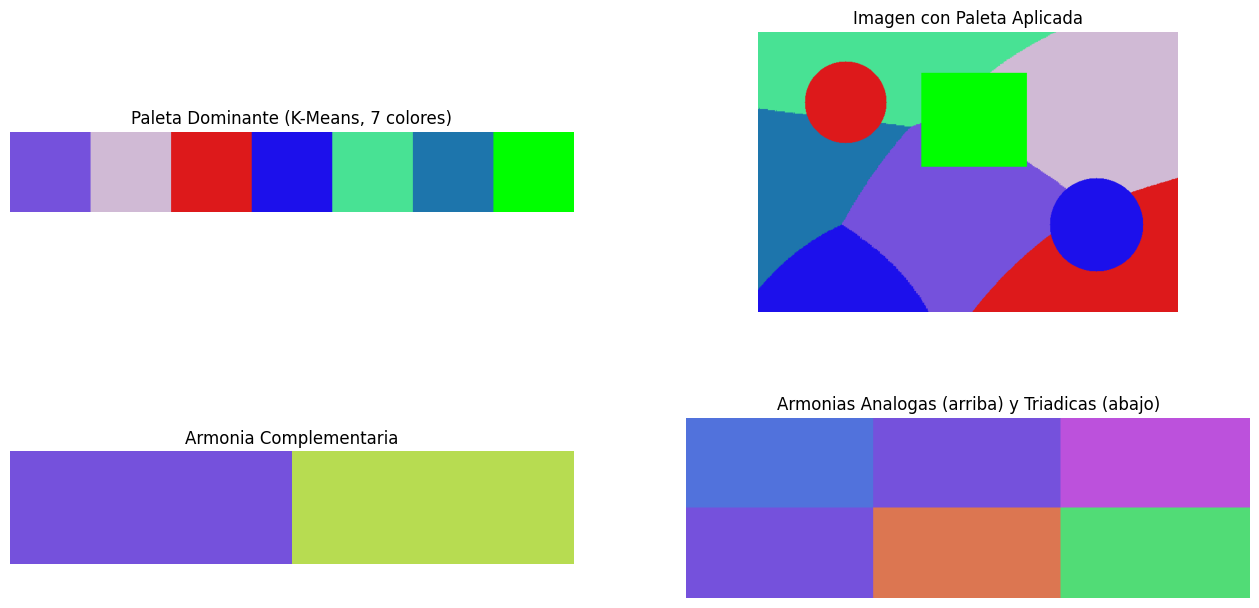

In [8]:
def extract_palette_kmeans(image_rgb: np.ndarray, k: int = 7):
    pixels = image_rgb.reshape(-1, 3).astype(np.float32)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 40, 0.2)
    _compactness, labels, centers = cv2.kmeans(
        pixels,
        k,
        None,
        criteria,
        8,
        cv2.KMEANS_PP_CENTERS
    )

    centers_uint8 = centers.astype(np.uint8)
    labels_flat = labels.flatten()
    counts = np.bincount(labels_flat, minlength=k)
    order = np.argsort(counts)[::-1]

    sorted_centers = centers_uint8[order]
    sorted_counts = counts[order]
    return sorted_centers, sorted_counts, labels_flat, centers_uint8

def palette_image(colors_rgb: np.ndarray, width: int = 700, height: int = 100) -> np.ndarray:
    n = len(colors_rgb)
    block_width = width // n
    canvas = np.zeros((height, width, 3), dtype=np.uint8)
    for idx, color in enumerate(colors_rgb):
        start = idx * block_width
        end = width if idx == n - 1 else (idx + 1) * block_width
        canvas[:, start:end] = color
    return canvas

def hue_shift_color(color_rgb: np.ndarray, shift_h_units: int) -> np.ndarray:
    color_pixel = color_rgb.reshape(1, 1, 3).astype(np.uint8)
    hsv = cv2.cvtColor(color_pixel, cv2.COLOR_RGB2HSV)
    hsv[..., 0] = (hsv[..., 0].astype(np.int16) + shift_h_units) % 180
    shifted = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)
    return shifted.reshape(3)

palette_colors, palette_counts, palette_labels, palette_centers = extract_palette_kmeans(image_rgb, k=7)
palette_rgb_image = palette_image(palette_colors)
save_rgb_image(palette_rgb_image, 'palette_dominant_colors')

dominant_color = palette_colors[0]
complementary_palette = np.array([dominant_color, hue_shift_color(dominant_color, 90)], dtype=np.uint8)
analogous_palette = np.array([hue_shift_color(dominant_color, -15), dominant_color, hue_shift_color(dominant_color, 15)], dtype=np.uint8)
triadic_palette = np.array([dominant_color, hue_shift_color(dominant_color, 60), hue_shift_color(dominant_color, -60)], dtype=np.uint8)

save_rgb_image(palette_image(complementary_palette), 'palette_complementary')
save_rgb_image(palette_image(analogous_palette), 'palette_analogous')
save_rgb_image(palette_image(triadic_palette), 'palette_triadic')

# Aplicacion de la paleta a la imagen (cuantizacion por clusters).
quantized_image = palette_centers[palette_labels].reshape(image_rgb.shape)
save_rgb_image(quantized_image, 'palette_applied_quantized')

plt.figure(figsize=(16, 8))
plt.subplot(2, 2, 1)
plt.imshow(palette_rgb_image)
plt.title('Paleta Dominante (K-Means, 7 colores)')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(quantized_image)
plt.title('Imagen con Paleta Aplicada')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(palette_image(complementary_palette, width=500))
plt.title('Armonia Complementaria')
plt.axis('off')

plt.subplot(2, 2, 4)
harmonies_grid = np.vstack([
    palette_image(analogous_palette, width=500, height=80),
    palette_image(triadic_palette, width=500, height=80)
])
plt.imshow(harmonies_grid)
plt.title('Armonias Analogas (arriba) y Triadicas (abajo)')
plt.axis('off')

save_current_figure('palette_summary')
plt.show()

## 7) Analisis de histogramas

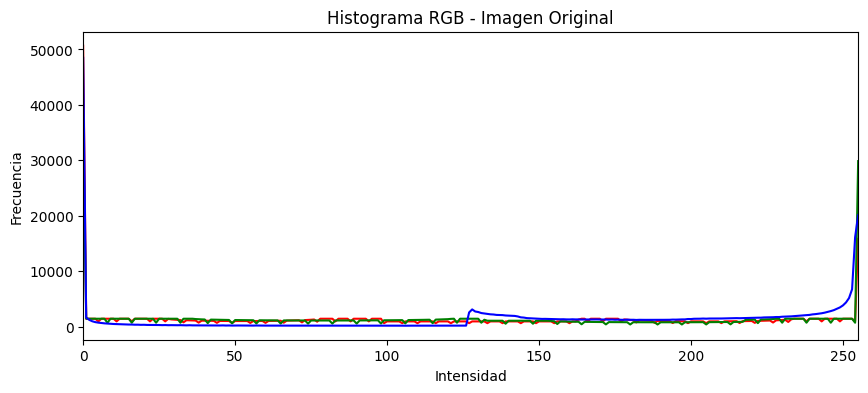

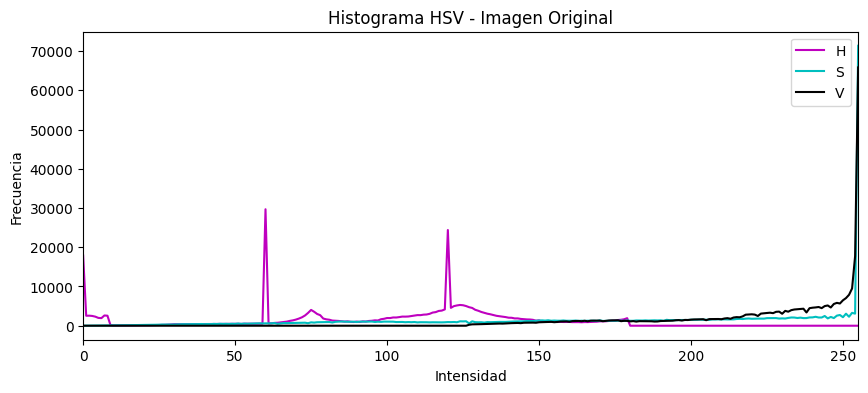

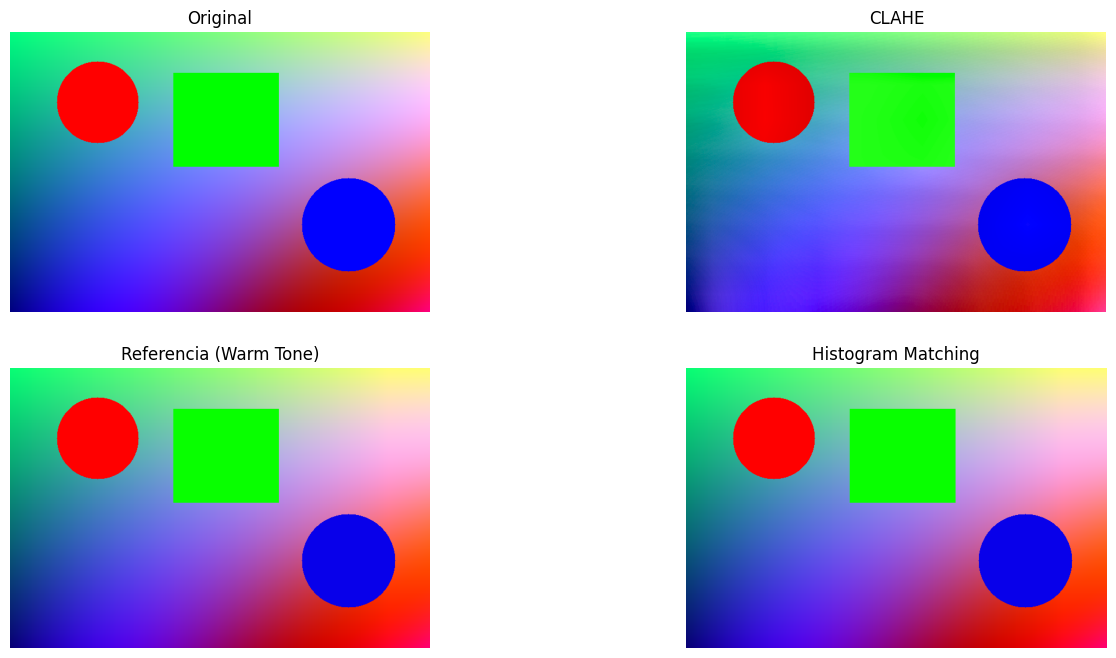

In [9]:
def plot_rgb_histogram(image_rgb: np.ndarray, title: str):
    colors = ['r', 'g', 'b']
    plt.figure(figsize=(10, 4))
    for idx, color in enumerate(colors):
        hist = cv2.calcHist([image_rgb], [idx], None, [256], [0, 256])
        plt.plot(hist, color=color, linewidth=1.5)
    plt.title(title)
    plt.xlabel('Intensidad')
    plt.ylabel('Frecuencia')
    plt.xlim([0, 255])

def plot_hsv_histogram(image_hsv: np.ndarray, title: str):
    channels = ['H', 'S', 'V']
    colors = ['m', 'c', 'k']
    plt.figure(figsize=(10, 4))
    for idx, (channel_name, color) in enumerate(zip(channels, colors)):
        hist = cv2.calcHist([image_hsv], [idx], None, [256], [0, 256])
        plt.plot(hist, color=color, linewidth=1.5, label=channel_name)
    plt.title(title)
    plt.xlabel('Intensidad')
    plt.ylabel('Frecuencia')
    plt.xlim([0, 255])
    plt.legend()

plot_rgb_histogram(image_rgb, 'Histograma RGB - Imagen Original')
save_current_figure('histogram_rgb')
plt.show()

plot_hsv_histogram(hsv_image, 'Histograma HSV - Imagen Original')
save_current_figure('histogram_hsv')
plt.show()

# CLAHE (ecualizacion adaptativa) aplicado sobre canal L en LAB.
lab_for_clahe = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2LAB)
l_channel, a_channel, b_channel = cv2.split(lab_for_clahe)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
l_clahe = clahe.apply(l_channel)
clahe_lab = cv2.merge((l_clahe, a_channel, b_channel))
clahe_image = cv2.cvtColor(clahe_lab, cv2.COLOR_LAB2RGB)
save_rgb_image(clahe_image, 'histogram_clahe')

# Matching de histogramas entre imagen original y referencia.
reference_image = warm_tone_image
matched_image = exposure.match_histograms(image_rgb, reference_image, channel_axis=-1)
matched_image = np.clip(matched_image, 0, 255).astype(np.uint8)
save_rgb_image(matched_image, 'histogram_matching')

plt.figure(figsize=(16, 8))
hist_items = [
    ('Original', image_rgb),
    ('CLAHE', clahe_image),
    ('Referencia (Warm Tone)', reference_image),
    ('Histogram Matching', matched_image)
]

for index, (title, image_to_show) in enumerate(hist_items, start=1):
    plt.subplot(2, 2, index)
    plt.imshow(image_to_show)
    plt.title(title)
    plt.axis('off')

save_current_figure('histogram_summary')
plt.show()

In [10]:
generated_files = sorted(MEDIA_DIR.glob(f'{OUTPUT_PREFIX}*'))
print('Archivos exportados:')
for path in generated_files:
    print(f' - {path.name}')

Archivos exportados:
 - python_base_image_preview.png
 - python_channels_hsl.png
 - python_channels_hsv.png
 - python_channels_lab.png
 - python_channels_rgb.png
 - python_channels_ycrcb.png
 - python_conversion_overview.png
 - python_grading_cool_tone.png
 - python_grading_instagram_style.png
 - python_grading_lut_curves.png
 - python_grading_selective_color.png
 - python_grading_summary.png
 - python_grading_warm_tone.png
 - python_gray_image.png
 - python_histogram_clahe.png
 - python_histogram_hsv.png
 - python_histogram_matching.png
 - python_histogram_rgb.png
 - python_histogram_summary.png
 - python_hsv_cylindrical_scatter.png
 - python_input_image.png
 - python_manip_hist_equalized_gray.png
 - python_manip_hue_rotated.png
 - python_manip_lab_luminance.png
 - python_manip_saturation_up.png
 - python_manip_white_balance.png
 - python_manipulation_summary.png
 - python_mask_blue.png
 - python_mask_green.png
 - python_mask_red.png
 - python_objects_blue.png
 - python_objects_combin